# Week 4 · Day 12 — Responsible AI & Practical Limitations

**Course:** IPAM USL 5-Week Short Course: Introduction to Artificial Intelligence *(Introductory tier)*

**Facilitator:** Solomon Wilson MBCS | PhD Student, Computer Science | Deputy HOD Transport Planning & Operations | HOD, IT & Audit Supervisor, SLPTA

**Mode:** Google Colab (zero-install)

**Mental model layer:** L12 — Responsible AI

**Running scenario:** Route **R12** (Wilberforce → CBD) — operator OP-104, 25-minute delay
**Module:** 3 · **Week:** 5 · **Tier:** Intro
**New concept:** Responsible AI means asking who is harmed if this system fails
**Deliverable wired in:** D2 — Ethics Checklist (10%)

## Learning objectives
By the end of today you will be able to:
- Spot **bias**: how an accurate model can still be **unfair** when used the wrong way.
- Explain LLM **hallucination** and why grounding matters.
- Complete an **AI Ethics Checklist** for your capstone (**Deliverable 2**).

## Why this matters for SLPTA

As a public regulatory authority, SLPTA is accountable for the decisions its tools influence. A model that is 80% accurate can still be **unfair** if it penalises operators for things outside their control — or **wrong** in ways that sound confident. Today we look both risks in the eye before anyone deploys anything.

## Environment setup

In [1]:
# Today's bias analysis is key-free; google-genai is installed only for consistency.
!pip install -q google-genai
print("Environment ready.")

Environment ready.


In [2]:
# --- Standard SLPTA bootstrap (identical in every notebook) ----------------
import sys
from pathlib import Path
for candidate in [Path.cwd(), *Path.cwd().parents,
                  Path("/content/IPAM_USL_Intro_AI_5Week")]:
    if (candidate / "shared" / "slpta_bootstrap.py").exists():
        sys.path.insert(0, str(candidate / "shared"))
        break

from slpta_bootstrap import (MODEL, ensure_course_data, get_client,
                             load_route12_context, load_route_logs,
                             load_complaints, load_routes, load_operators)

ensure_course_data()
print("Model configured:", MODEL)
print(load_route12_context())

Model configured: gemini-2.0-flash
Route R12 (Wilberforce → CBD). The 07:45 service, operated by OP-104 on vehicle SLPTA-1142, departed 25 minutes late. Recorded cause: Heavy traffic on Wilkinson Road. About 40 passengers were affected and the dispatch desk received multiple complaints. (Synthetic SLPTA scenario — no real data.)


## Concept — first principles

- **Bias**: the data reflects the world, including things that are unfair. A model trained on it can repeat or amplify that.
- **Hallucination**: an LLM predicts plausible text and can state false things confidently (Day 9).
- **Explainability**: can we say *why* the model decided as it did? Simple models (trees) are easier to explain than deep ones.
- **"Should we build this?"**: sometimes the responsible answer is not to automate a decision at all.

<p align="center"></p>

<!-- cell-diagram:c09 -->
<p align="center"></p>

### Check your understanding (before running)
Our Day 3 model flags trips likely to be badly delayed. **Predict:** if we used it to *rank operators*, would it judge them on their own performance — or partly on weather and time of day they cannot control?

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# --- 1. Data Loading and Cleaning ---
# Load synthetic SLPTA route logs and remove exact duplicates to ensure data quality.
logs = load_route_logs().drop_duplicates()

# Filter out extreme outliers (delays over 3 hours) to prevent them from skewing the model.
logs = logs[logs["delay_minutes"] < 180].copy()

# Handle missing values:
# - For categorical 'weather', use the most frequent value (mode).
# - For numerical 'passenger_count', use the middle value (median) to be robust against outliers.
logs["weather"] = logs["weather"].fillna(logs["weather"].mode()[0])
logs["passenger_count"] = logs["passenger_count"].fillna(logs["passenger_count"].median())
logs = logs.reset_index(drop=True)

# --- 2. Feature Engineering and Labeling ---
# Define our target: 1 if the trip is delayed more than 15 minutes, otherwise 0.
y = (logs["delay_minutes"] > 15).astype(int)

# Select features and use One-Hot Encoding for categorical variables like route and weather.
X = pd.get_dummies(logs[["route_id", "peak_period", "weather", "cause_category",
                         "scheduled_hour", "distance_km", "passenger_count"]])

# --- 3. Model Training ---
# Split data into training (75%) and testing (25%) sets, ensuring the delay ratio remains balanced.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

# Initialize and train a Decision Tree classifier.
# We limit max_depth to 5 to keep the model explainable and prevent overfitting.
model = DecisionTreeClassifier(max_depth=5, random_state=0).fit(Xtr, ytr)

# --- 4. Bias Analysis ---
# Apply the model back to the logs to see which trips would be 'flagged' as high risk.
logs["flagged"] = model.predict(X)   # 1 = model predicts 'badly delayed'

# Print the share of trips flagged to investigate potential bias in environmental factors.
print("Share of trips the model FLAGS, by weather:")
print((logs.groupby("weather")["flagged"].mean() * 100).round(1).to_string())

print("\nShare of trips the model FLAGS, by peak period:")
print((logs.groupby("peak_period")["flagged"].mean() * 100).round(1).to_string())

Share of trips the model FLAGS, by weather:
weather
Harmattan     13.0
Heavy Rain    84.0
Rain          11.6
Sunny         14.8

Share of trips the model FLAGS, by peak period:
peak_period
False    13.8
True     39.6


<!-- cell-diagram:c11 -->
<p align="center"></p>

### Check your understanding (before running)
The cell above showed the raw flag rates. This cell will draw a bar chart of the same data.
- Which weather condition do you expect to have the tallest bar?
- If an operator runs mostly Sunny routes, how does the chart help their case?

*Write your prediction, then run.*

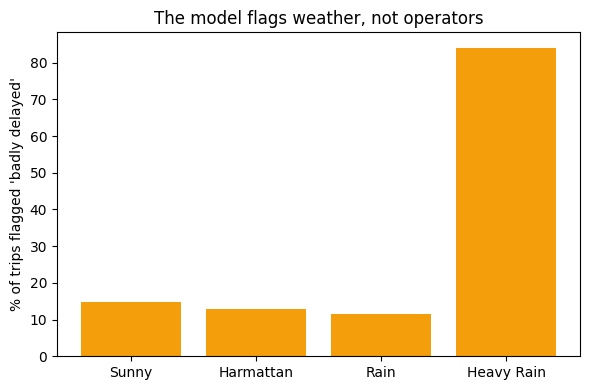

In [4]:
import matplotlib.pyplot as plt

# Define a logical order for weather severity to make the chart easier to read
order = ["Sunny", "Harmattan", "Rain", "Heavy Rain"]

# Calculate the percentage of trips flagged by the model for each weather type
# .reindex(order) ensures the bars appear in our specified order regardless of data frequency
rates = (logs.groupby("weather")["flagged"].mean() * 100).reindex(order)

# --- Create the Visual Representation ---
plt.figure(figsize=(6, 4))
plt.bar(order, rates.values, color="#f59e0b") # Use SLPTA amber color for consistency

# Labeling for clarity and professional presentation
plt.ylabel("% of trips flagged 'badly delayed'")
plt.title("The model flags weather, not operators")

# Adjust layout to ensure no labels are cut off
plt.tight_layout()
plt.show()

The model flags Heavy-Rain and peak-hour trips far more often than sunny, off-peak ones. That is *correct* — those trips really do run late. But it means an operator who happens to run more rainy or peak services would be flagged more **through no fault of their own**. An accurate model can be an **unfair** yardstick. The fix is not a better model; it is using it for the right purpose (pre-warning passengers) and not the wrong one (ranking operators).

### Exercise — check another grouping

Change `group_by` below to `"route_id"` (then `"operator_id"`) and re-run to see whether flags concentrate on particular routes or operators — and ask whether that would be fair to act on.

<!-- cell-diagram:c15 -->
<p align="center"></p>

### Check your understanding (before running)
You are about to change `group_by` from `"weather"` to `"route_id"`.
- Which routes do you expect to have the **highest** flag rate? Why?
- If Route R12 is flagged the most, does that mean OP-104 is the worst operator?

*Write your prediction, then change the string and run.*

In [5]:
# --- Bias Exploration Exercise ---
# This block allows us to check if the model disproportionately targets specific groups.
# TODO: change group_by to "route_id", then "operator_id".
group_by = "weather"   # <-- Change this string to explore other dimensions of the data

print(f"Flag rate by {group_by}:")

# 1. Group the logs by the chosen category.
# 2. Calculate the mean of the 'flagged' column (results in a 0.0 to 1.0 range).
# 3. Multiply by 100 to get a percentage.
# 4. Round for readability and sort descending to see the most 'flagged' groups at the top.
analysis = (logs.groupby(group_by)["flagged"].mean() * 100).round(1)
print(analysis.sort_values(ascending=False).to_string())

Flag rate by weather:
weather
Heavy Rain    84.0
Sunny         14.8
Harmattan     13.0
Rain          11.6


## A note on hallucination

On Day 9 we saw the model can sound confident and still be wrong. That is why every LLM prompt in this course **pasted the source text** and said *"use only the facts stated."* For SLPTA, treat any LLM output that affects passengers, money, or safety as a **draft a human must verify** — never an authority on its own.

## Deliverable 2 — AI Ethics Checklist (graded, 10%)

Complete this checklist for **your** capstone project. Identify at least **two risks** and a mitigation for each. *Due end of Day 12.*

### My AI Ethics Checklist
*Double-click to edit.*

**Project:** ____________________

| Question | My answer |
|----------|-----------|
| **Who is affected** by this model's output (passengers, operators, staff)? | |
| **What is the worst mistake** it could make, and who does it hurt? | |
| **Bias check:** could it judge a group on something they don't control? | |
| **Hallucination/error check:** does any output go to a human before it acts? | |
| **Risk 1** + mitigation | |
| **Risk 2** + mitigation | |
| **Should we build this at all?** (Yes/No and why) | |

## Check your understanding
1. How can a model be **accurate** and yet **unfair**? Use the flag-rate result in your answer.
2. What is a hallucination, and what is our standard defence against it in this course?
3. Name one SLPTA decision that should **not** be fully automated, and say why.

### Your answers
*Double-click to edit this cell and type your answers here.*

1.
2.
3.

## If you remember one thing today…

> **An accurate model can still be unfair or wrong — ask who it affects and where it is weakest before you deploy it.**

## Submission checklist
- [ ] Run every code cell successfully (top to bottom)
- [ ] Complete the exercise (fill every blank / make the requested change)
- [ ] Answer the **Check your understanding** questions in the markdown cell provided
- [ ] Save a clean copy of the notebook (*File → Save a copy in Drive*)